# Required Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

## Change Settings for df handling

In [2]:
'''from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)'''

'from itables import init_notebook_mode\ninit_notebook_mode(all_interactive=True)'

---
# Exercise 1
---

---

## 1. Select use cases to be considered in the strategic plan

Identify and justify the use cases that you will consider for the development of **airside facility requirements** in the strategic plan of **AEROVALE Regional Airport**.  

Clearly specify which **new or modified airside infrastructure** is required to accommodate the new categories of airport users included in your use cases (e.g., **UAVs**, **eVTOL aircraft**).

---

> **Note**  
> When determining facility requirements, **focus exclusively on the airside part** of AEROVALE Regional Airport  
> *(i.e., the stands, taxiways, runways, vertiports, etc.).*

---

### Documentation

Describe the following:

- The **selected use cases**
- The **new or modified airport users**
- The **required airside infrastructure**
- The **associated assumptions**

---

## Documentation

### Use Case 1: Urban Air Mobility (UAM)

**New or modified airport users**

- Uber drones  
- Passenger transport between the airport and the city (approx. 70 km) and other locations

**Required airside infrastructure**

- Landing and parking area for UAM outside of the active runway zone  
- Access from the terminal to the UAM operation zone  
- Recharging facilities  
- Energy facilities  

**Associated assumptions**

- UAM will be used for passenger transport between the airport and the city and other locations.

---

### Use Case 2: UAV Operations

**New or modified airport users**

- Cargo delivery drones

**Required airside infrastructure**

- Parking area for drones  
- Loading area for cargo  
- Recharging facilities  
- Cargo transfer site  

**Associated assumptions**

- UAVs will be used to transport cargo between the airport and the city.

---

### Use Case 3: Growth of Conventional Traffic

**New or modified airport users**

- New airlines  
- Existing airlines increasing the number of flights  
- Conventional air traffic (passenger and cargo)

**Required airside infrastructure**

- Possible expansion of the terminal depending on demand

**Associated assumptions**

- Demand for conventional air traffic will increase.

## 2. Generate at least 1000 demand scenarios using Geometric Brownian Motion (GBM)

Generate **at least 1000 demand scenarios** for your engineering system using **Geometric Brownian Motion (GBM)**.

Estimate the **GBM parameters** from historical demand data for your selected system, following the method introduced in **Video 2**.

Generate demand scenarios covering a **planning horizon of at least 20 years**.

---

> **Hint**  
> To estimate realistic **GBM parameters**, use the historical demand data of **AEROVALE Regional Airport** provided in the file `aerovale_demand.csv`.  
>  
> The dataset covers the period **1982–2024**.

---

#### Load historical data

In [3]:
df = pd.read_csv("aerovale_demand.csv", delimiter=";")
df

,Year,Flight_Movements,Passengers
0,1982,18500,210000
1,1983,18800,218000
2,1984,19100,225000
3,1985,19500,235000
4,1986,19800,245000
5,1987,20200,258000
6,1988,20600,270000
7,1989,21000,285000
8,1990,21500,300000
9,1991,21800,310000


#### Plot the time series

##### Flight Movements per Year

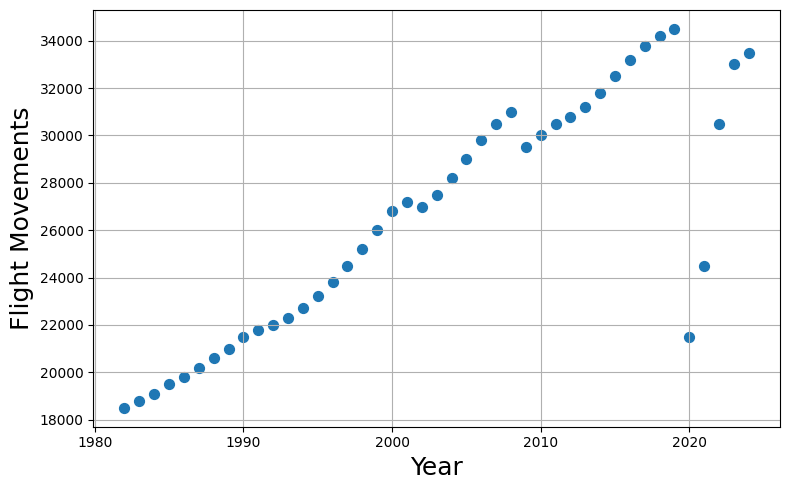

In [4]:
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(df["Year"], df["Flight_Movements"], s=50)

ax.set_xlabel("Year", fontsize=18)
ax.set_ylabel("Flight Movements", fontsize=18)

ax.grid(True)

plt.tight_layout()
plt.show()

##### Passengers per Year

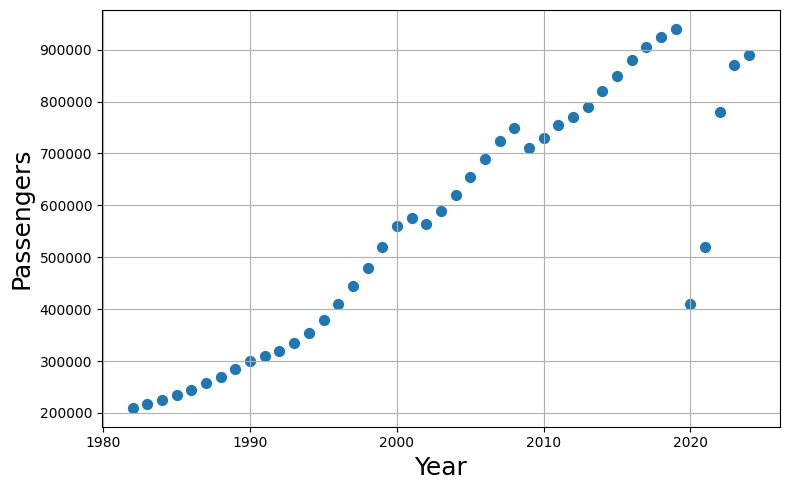

In [5]:
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(df["Year"], df["Passengers"], s=50)

ax.set_xlabel("Year", fontsize=18)
ax.set_ylabel("Passengers", fontsize=18)

ax.grid(True)

plt.tight_layout()
plt.show()

#### Determine Parameters

##### Compute Log-Returns

In [6]:
df["r_passengers"] = np.log(df["Passengers"] / df["Passengers"].shift(1))
df["r_movements"] = np.log(df["Flight_Movements"] / df["Flight_Movements"].shift(1))

##### Compute mu and sigma (with and without COVID-years)

In [7]:
# Remove COVID-years
subset = df[~df["Year"].isin([2020, 2021, 2022])]

# Compute mu (without covid)
mu_passengers = subset['r_passengers'].dropna().mean()
mu_flights = subset['r_movements'].dropna().mean()

# Compute std (without covid)
std_passengers = subset['r_passengers'].dropna().std(ddof=0)
std_flights = subset['r_movements'].dropna().std(ddof=0)

print("\nEstimated GBM Parameters (without COVID-years)\n")
print(f"{'Variable':<18} {'mu':>10} {'sigma':>10}")
print("-" * 40)
print(f"{'Flight Movements':<18} {mu_flights:>10.4f} {std_flights:>10.4f}")
print(f"{'Passengers':<18} {mu_passengers:>10.4f} {std_passengers:>10.4f}")


# -----------------------
# With COVID-years
# -----------------------
subset_all = df

# Compute mu
mu_passengers_all = subset_all['r_passengers'].dropna().mean()
mu_flights_all = subset_all['r_movements'].dropna().mean()

# Compute std
std_passengers_all = subset_all['r_passengers'].dropna().std(ddof=0)
std_flights_all = subset_all['r_movements'].dropna().std(ddof=0)

print("\nEstimated GBM Parameters (all years)\n")
print(f"{'Variable':<18} {'mu':>10} {'sigma':>10}")
print("-" * 40)
print(f"{'Flight Movements':<18} {mu_flights_all:>10.4f} {std_flights_all:>10.4f}")
print(f"{'Passengers':<18} {mu_passengers_all:>10.4f} {std_passengers_all:>10.4f}")


Estimated GBM Parameters (without COVID-years)

Variable                   mu      sigma
----------------------------------------
Flight Movements       0.0184     0.0162
Passengers             0.0418     0.0272

Estimated GBM Parameters (all years)

Variable                   mu      sigma
----------------------------------------
Flight Movements       0.0141     0.0850
Passengers             0.0344     0.1509


#### Plot the distribution of the log-returns

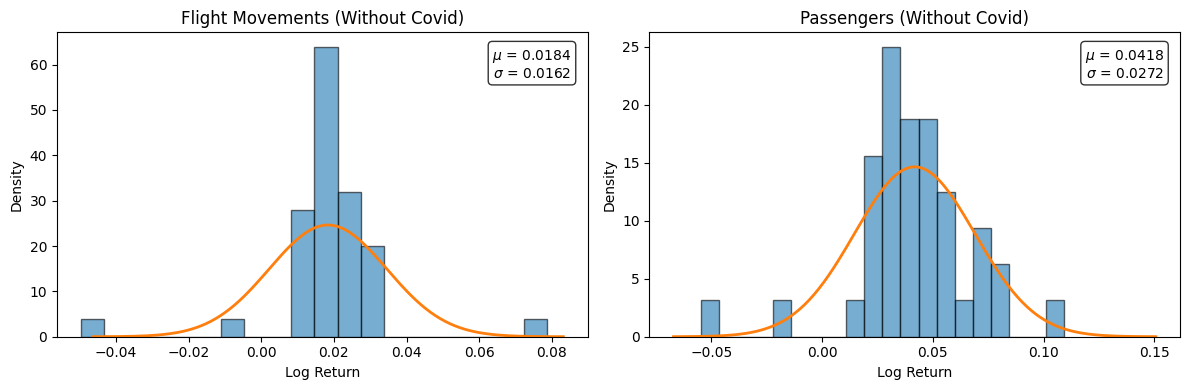

In [8]:
# -----------------------
# Plot
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# -----------------------
# Flights (Without Covid)
# -----------------------
data_flights = subset['r_movements'].dropna()
x = np.linspace(mu_flights-4*std_flights, mu_flights+4*std_flights, 200)

axes[0].hist(data_flights, bins=20, density=True, alpha=0.6, edgecolor="black")
axes[0].plot(x, norm.pdf(x, mu_flights, std_flights), linewidth=2)

axes[0].set_title("Flight Movements (Without Covid)")
axes[0].set_xlabel("Log Return")
axes[0].set_ylabel("Density")

axes[0].text(
    0.97, 0.95,
    f"$\\mu$ = {mu_flights:.4f}\n$\\sigma$ = {std_flights:.4f}",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# -----------------------
# Passengers (Without Covid)
# -----------------------
data_passengers = subset['r_passengers'].dropna()
x = np.linspace(mu_passengers-4*std_passengers, mu_passengers+4*std_passengers, 200)

axes[1].hist(data_passengers, bins=20, density=True, alpha=0.6, edgecolor="black")
axes[1].plot(x, norm.pdf(x, mu_passengers, std_passengers), linewidth=2)

axes[1].set_title("Passengers (Without Covid)")
axes[1].set_xlabel("Log Return")
axes[1].set_ylabel("Density")

axes[1].text(
    0.97, 0.95,
    f"$\\mu$ = {mu_passengers:.4f}\n$\\sigma$ = {std_passengers:.4f}",
    transform=axes[1].transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

### Generate Scenarios

In [9]:
# Simulation parameters
n_scenarios = 1000   # number of simulated paths
n_years = 20         # simulation horizon
dt = 1               # time step (1 year)
seed = 42            # random seed for reproducibility

rng = np.random.default_rng(seed)

# -----------------------
# Flight Movements
# -----------------------

# Initial value (last observed data point)
Y0_movements = df["Flight_Movements"].iloc[-1]

# Random shocks for movements
eps_movements = rng.normal(loc=0, scale=1, size=(n_years, n_scenarios))

# Initialize scenario matrix
movement_scenarios = np.zeros((n_years + 1, n_scenarios))
movement_scenarios[0, :] = Y0_movements

# Geometric Brownian Motion simulation
for t in range(n_years):
    movement_scenarios[t + 1, :] = movement_scenarios[t, :] * np.exp(
        mu_flights * dt + std_flights * eps_movements[t, :] * np.sqrt(dt)
    )

# -----------------------
# Passengers
# -----------------------

# Initial value (last observed data point)
Y0_passengers = df["Passengers"].iloc[-1]

# Random shocks for passengers
eps_passengers = rng.normal(loc=0, scale=1, size=(n_years, n_scenarios))

# Initialize scenario matrix
passenger_scenarios = np.zeros((n_years + 1, n_scenarios))
passenger_scenarios[0, :] = Y0_passengers

# Geometric Brownian Motion simulation
for t in range(n_years):
    passenger_scenarios[t + 1, :] = passenger_scenarios[t, :] * np.exp(
        mu_passengers * dt + std_passengers * eps_passengers[t, :] * np.sqrt(dt)
    )

#### Plot the generated scenarios

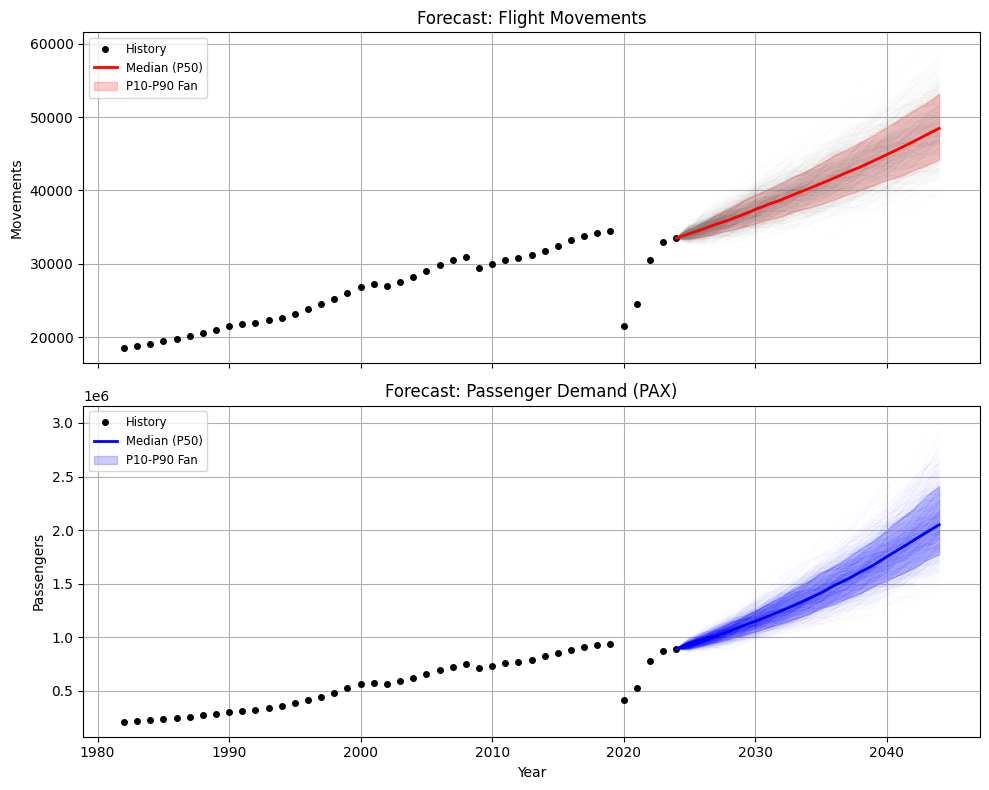

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Time axis for the simulation horizon
years_future = np.arange(
    df["Year"].iloc[-1],
    df["Year"].iloc[-1] + n_years + 1
)

# -----------------------
# Flight Movements
# -----------------------

# Plot historical observations and simulated paths
axes[0].plot(df["Year"], df["Flight_Movements"], 'ko', label="History", markersize=4)
axes[0].plot(years_future, movement_scenarios, color='gray', alpha=0.02, lw=0.5)

# Compute prediction intervals and median path
mov_q10 = np.quantile(movement_scenarios, 0.10, axis=1)
mov_q50 = np.quantile(movement_scenarios, 0.50, axis=1)
mov_q90 = np.quantile(movement_scenarios, 0.90, axis=1)

# Plot median forecast and uncertainty band
axes[0].plot(years_future, mov_q50, 'r-', lw=2, label="Median (P50)")
axes[0].fill_between(years_future, mov_q10, mov_q90, color='red', alpha=0.2, label="P10-P90 Fan")

axes[0].set_title("Forecast: Flight Movements")
axes[0].set_ylabel("Movements")
axes[0].legend(loc='upper left', fontsize='small')
axes[0].grid(True)


# -----------------------
# Passengers
# -----------------------

# Plot historical observations and simulated paths
axes[1].plot(df["Year"], df["Passengers"], 'ko', label="History", markersize=4)
axes[1].plot(years_future, passenger_scenarios, color='blue', alpha=0.02, lw=0.5)

# Compute prediction intervals and median path
pax_q10 = np.quantile(passenger_scenarios, 0.10, axis=1)
pax_q50 = np.quantile(passenger_scenarios, 0.50, axis=1)
pax_q90 = np.quantile(passenger_scenarios, 0.90, axis=1)

# Plot median forecast and uncertainty band
axes[1].plot(years_future, pax_q50, 'b-', lw=2, label="Median (P50)")
axes[1].fill_between(years_future, pax_q10, pax_q90, color='blue', alpha=0.2, label="P10-P90 Fan")

axes[1].set_title("Forecast: Passenger Demand (PAX)")
axes[1].set_ylabel("Passengers")
axes[1].set_xlabel("Year")
axes[1].legend(loc='upper left', fontsize='small')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3. Generate at least 1000 scenarios specifying the market share of UAVs, eVTOLs, etc.

Generate **at least 1000 scenarios** for your engineering system specifying the **market share of UAVs, eVTOLs, and other new airport user groups**.

In order to derive **airside facility requirements** for **AEROVALE Regional Airport**, you need—**in addition to the demand scenarios (see Task 2)**—scenarios that describe:

- **when new airport user groups** (e.g., UAVs, eVTOL aircraft) **enter the market**, and  
- **how their market shares evolve over time**.

Use the **same planning horizon as in Task 2**.

---

> **Note**  
> The generation of such scenarios is **not explained in the videos or the lecture notes**.  
> Therefore, conduct a **brief literature review** and develop **your own approach** for generating scenarios that describe the market shares of these user groups.

---

### Documentation

Describe:

- The **method you selected or developed** to generate the market share scenarios  
- A **justification of your method** (i.e., explain why you consider this approach appropriate)

---

# Market Share Scenario Generation (S-Curves)

## 1. Methodology

Market share scenarios are generated using S-curves to represent the adoption of new aviation technologies over time.

The model considers three market segments:
- Conventional aviation
- Unmanned Aerial Vehicles (UAV)
- eVTOL operations

---

### 1.1 Scenario Generation

For each scenario:

- An entry year is sampled for UAV and eVTOL from predefined ranges  
- A maximum market share is sampled  
- A growth rate is sampled  
- A midpoint year is defined as a few years after market entry  

Before the entry year, the market share is set to 0.  
From the entry year onwards, the market share follows an S-curve.

This process is applied independently to UAV and eVTOL.

---

### 1.2 Feasibility Constraint

Since the total market share cannot exceed 100%, the following rule is applied:

- If UAV share + eVTOL share exceeds 1, both shares are scaled down proportionally  

The conventional share is then calculated as:

Conventional share = 1 − UAV share − eVTOL share

---

### 1.3 Scenario Output

This approach generates a large number of possible future trajectories.  
For each year, the distribution of outcomes can be summarized using percentiles (e.g. P10, P50, P90).

---

## 2. Justification

This approach is suitable to model the uncertain adoption of UAV and eVTOL.

### Realistic Adoption Behavior
S-curves capture:
- Slow initial uptake  
- Accelerated growth  
- Saturation  

### Representation of Uncertainty
Uncertainty is included by sampling:
- Entry year  
- Maximum market share  
- Growth rate  
- Timing of rapid growth  

### Consistent Market Shares
The model ensures:
- No negative values  
- Total market share equals 1  

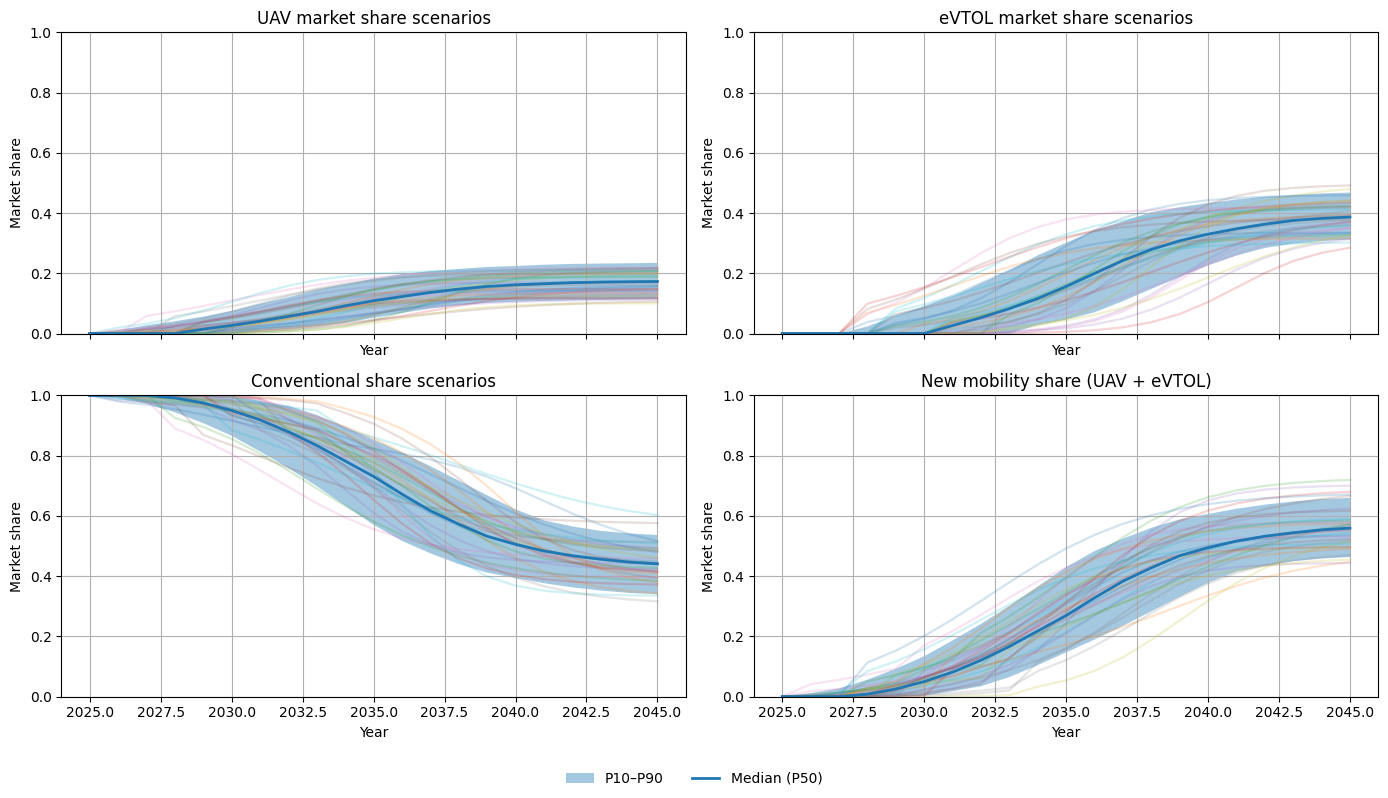

In [11]:
# ============================================================
# SETTINGS (EDIT ONLY HERE)
# ============================================================

start_year = 2025
n_years = 20
n_scenarios = 1000
seed = 42

# UAV parameter ranges
entry_uav_range = (2026, 2032)
max_uav_range = (0.10, 0.25)
growth_uav_range = (0.3, 0.7)
mid_delay_uav_range = (3, 8)

# eVTOL parameter ranges
entry_evtol_range = (2028, 2035)
max_evtol_range = (0.3, 0.5)
growth_evtol_range = (0.3, 0.7)
mid_delay_evtol_range = (3, 8)

# Number of example paths shown in each plot
n_example_paths = 30

# ============================================================
# PREP
# ============================================================

# Random number generator for reproducible sampling
rng = np.random.default_rng(seed)

# Time axis of the forecast horizon
years = np.arange(start_year, start_year + n_years + 1)

# ============================================================
# FUNCTIONS
# ============================================================

def s_curve(years, entry_year, max_share, growth_rate, mid_year):
    # Initialize market shares with zero before market entry
    shares = np.zeros_like(years, dtype=float)

    # Apply S-curve only from the entry year onwards
    mask = years >= entry_year
    shares[mask] = max_share / (1 + np.exp(-growth_rate * (years[mask] - mid_year)))

    return shares

def fan_stats(x):
    # Calculate percentiles across all simulated scenarios
    q10 = np.quantile(x, 0.10, axis=0)
    q50 = np.quantile(x, 0.50, axis=0)
    q90 = np.quantile(x, 0.90, axis=0)
    return q10, q50, q90

def plot_share_fan(ax, years, share_paths, title):
    # Compute percentile bands of the simulated paths
    q10, q50, q90 = fan_stats(share_paths)

    # Randomly select a subset of scenarios to visualize example paths
    idx = rng.choice(
        share_paths.shape[0],
        size=min(n_example_paths, share_paths.shape[0]),
        replace=False
    )
    ax.plot(years, share_paths[idx].T, linewidth=1.6, alpha=0.20)

    # Plot percentile fan and median trajectory
    ax.fill_between(years, q10, q90, alpha=0.4, label="P10–P90")
    ax.plot(years, q50, linewidth=2.0, label="Median (P50)")

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Market share")
    ax.set_ylim(0, 1)
    ax.grid(True)

# ============================================================
# SAMPLE PARAMETERS
# ============================================================

# Sample one parameter set per UAV scenario
entry_uav = rng.integers(*entry_uav_range, size=n_scenarios)
max_uav = rng.uniform(*max_uav_range, size=n_scenarios)
growth_uav = rng.uniform(*growth_uav_range, size=n_scenarios)

# Define midpoint as a delay after market entry
mid_uav = entry_uav + rng.integers(*mid_delay_uav_range, size=n_scenarios)

# Sample one parameter set per eVTOL scenario
entry_evtol = rng.integers(*entry_evtol_range, size=n_scenarios)
max_evtol = rng.uniform(*max_evtol_range, size=n_scenarios)
growth_evtol = rng.uniform(*growth_evtol_range, size=n_scenarios)

# Define midpoint as a delay after market entry
mid_evtol = entry_evtol + rng.integers(*mid_delay_evtol_range, size=n_scenarios)

# ============================================================
# GENERATE SCENARIOS
# ============================================================

# Store simulated market share paths for all technologies
uav_paths = np.zeros((n_scenarios, len(years)))
evtol_paths = np.zeros((n_scenarios, len(years)))
conv_paths = np.zeros((n_scenarios, len(years)))
new_paths = np.zeros((n_scenarios, len(years)))

for i in range(n_scenarios):
    # Generate one UAV and one eVTOL S-curve for scenario i
    uav = s_curve(years, entry_uav[i], max_uav[i], growth_uav[i], mid_uav[i])
    evtol = s_curve(years, entry_evtol[i], max_evtol[i], growth_evtol[i], mid_evtol[i])

    # Ensure that UAV and eVTOL shares together do not exceed 100%
    total_new = uav + evtol
    mask = total_new > 1
    uav[mask] = uav[mask] / total_new[mask]
    evtol[mask] = evtol[mask] / total_new[mask]

    # Conventional aviation takes the remaining market share
    conv = 1 - (uav + evtol)

    # Store results
    uav_paths[i] = uav
    evtol_paths[i] = evtol
    conv_paths[i] = conv
    new_paths[i] = uav + evtol

# ============================================================
# PLOT
# ============================================================

# Create subplot layout for all market segments
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

plot_share_fan(axes[0, 0], years, uav_paths, "UAV market share scenarios")
plot_share_fan(axes[0, 1], years, evtol_paths, "eVTOL market share scenarios")
plot_share_fan(axes[1, 0], years, conv_paths, "Conventional share scenarios")
plot_share_fan(axes[1, 1], years, new_paths, "New mobility share (UAV + eVTOL)")

# Add one shared legend for all subplots
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

## 4. Identify potential real options “in” and “on” systems

Identify potential real options “in” and “on” systems that could support the development of a flexible strategic plan for the airside infrastructure of *AEROVALE Regional Airport*.

---

### Documentation

Describe:

- At least two real options “in” systems  
- At least two real options “on” systems  
- How these options could be applied

#### 4.1 Options on Systems:
- **Option to Stage:** Start with a small cargo UAV area to test operations and gradually expand if needed. Initially, existing infrastructure (e.g. parts of the GA area) can be used.
- **Option to Defer:** Delay the construction of vertiports until sufficient demand is observed. However, the required space should be reserved.

#### 4.2 Options in Systems:
- **Pre-installed conduits for power cables:** eVTOL operations require electrical power. When building new apron sections or renovating existing ones, include empty conduits for future cable installation.
- **Scalable charging infrastructure:** Install a basic electrical setup that can be upgraded to higher capacity without major reconstruction.

## 5. Define a candidate flexibility

Define a **candidate flexibility** based on your considerations in the previous tasks, which you intend to use to **plan the system in a flexible manner**.

---

> **Hint**  
> Select a **relatively simple candidate flexibility**.  
>  
> You will later use this flexibility to **derive flexible facility requirements based on decision rules**.

---

### Documentation

Describe:

- The **selected candidate flexibility**
- Which **real option(s)** it is based on
- **How these option(s) operate**

---

#### eVTOL Vertipads

At the beginning, only a few eVTOL vertipads with charging stations are built. The location should be chosen such that eVTOLs can leave the airport without conflicting too much with conventional traffic. If demand increases, new vertipads can be added (option on system). The expansion can make use of pre-installed conduits for power cables (option in system). Further, the electrical power setup can be increased in a modular way if necessary (option in system).

---
# Exercise 2
---

## 6. Collect information on the revenue and cost functions of your system

Collect information on the **revenue and cost functions** of your system.

Identify the **operational and capital expenditures** incurred by the system, their **approximate magnitude**, and the **costs associated with capacity expansions**.

Identify the system’s **revenue streams** and describe **how they can be quantified**.

Define the **revenue and cost functions** that you will later use to compute the **expected net present value (ENPV)** of your system, including the **chosen functional forms** and their **parameterization**.

---

> **Hint**  
> See the **Airport Parking Garage Example** below for examples of revenue and cost functions that may inspire your own definitions.

---

### Documentation

Describe:

- Your **cost and revenue functions**
- All **parameters used** (e.g., unit cost per unit of capacity)
- **How each parameter was determined**
- An **assessment of the reliability of your estimates**

---

#### 6.1 Revenue Function

The revenue is defined as follows:

$$
\text{Revenue}_t = \text{Landing Fee}_t + \text{Charging Fee}_t
$$

with:

- $\text{Landing Fee}_t$: Fee charged to aircraft for landing at the airport  
- $\text{Charging Fee}_t$: Fee for charging eVTOLs

In [12]:
def revenue(landing_fee, charging_fee):
    return landing_fee + charging_fee

#### Landing Fee

Landing fees are defined as follows:

$$
\text{Landing Fee}_t = \min(\text{Demand}_t, \text{Capacity}_t) \cdot \text{Landing Fee}_{\text{eVTOL}}
$$

---

#### Parameters

In this simplified setup, only eVTOL landing fees are considered.  
The number of charged landings is limited by the available capacity.

- $\text{Demand}_t$: Total demand in period $t$  
- $\text{Capacity}_t$: Available eVTOL capacity in period $t$  
- $\text{Landing Fee}_{\text{eVTOL}}$: Fee per eVTOL landing  

In [13]:
def landing_fee(Demand, Capacity, Fee_eVTOL=250):
    used_flights = np.minimum(Demand, Capacity)
    return used_flights * Fee_eVTOL

#### Charging Fee

The charging fee represents the cost associated with recharging eVTOL aircraft.  
This cost does not apply to conventional aircraft, as they do not require electric charging infrastructure.

The charging fee is defined as follows:

$$
\text{Charging Fee}_t = \min(\text{Demand}_t, \text{Capacity}_t) \cdot \text{Charging Fee}_{\text{eVTOL}}
$$

---

#### Parameters

- $\text{Demand}_t$: Total demand in period $t$  
- $\text{Capacity}_t$: Available eVTOL capacity in period $t$  
- $\text{Charging Fee}_{\text{eVTOL}}$: Cost per eVTOL charging operation  

The number of charging operations is limited by the available capacity.

In [14]:
def charging_fee(Demand, Capacity, Charging_Fee_eVTOL=100):
    used_flights = np.minimum(Demand, Capacity)
    return used_flights * Charging_Fee_eVTOL

#### 6.2 Cost Function

The cost is defined as follows:

$$
\text{Cost}_t = \text{OPEX}_t + \text{CAPEX}_t
$$

with:

- $\text{OPEX}_t$: Operational expenditures (e.g. personnel, maintenance, energy costs)  
- $\text{CAPEX}_t$: Capital expenditures (e.g. infrastructure investments such as vertiports or charging stations)

In [15]:
def cost(OPEX, CAPEX):
    return OPEX + CAPEX

##### OPEX

OPEX is defined as follows:

$$
\text{OPEX}_t = \text{Maintenance Costs} \cdot \text{Stands}_t 
+ \text{Usage Costs} \cdot \min \left( \text{Demand}_t, \ \text{Capacity}_t \right)
$$

with:

- $\text{Maintenance Costs}$: Annual maintenance cost per stand  
- $\text{Usage Costs}$: Variable cost per eVTOL operation  
- $\text{Stands}_t$: Number of installed stands at time $t$  
- $\text{Demand}_t$: Total demand at time $t$  
- $\text{Capacity}_t$: Available system capacity at time $t$  

In this simplified setup, only eVTOL operations are considered.  
The number of processed flights is limited by the minimum of demand and available capacity.

In [16]:
def OPEX(Demand, Capacity, stands, maintenance_per_stand=50000, usage_cost=120):
    used_flights = np.minimum(Demand, Capacity)
    return maintenance_per_stand * stands + usage_cost * used_flights

##### CAPEX

CAPEX is defined as follows:

$$
\text{CAPEX}_t = \left( \text{Capacity}_t - \text{Capacity}_{t-1} \right)^{\alpha} \cdot \text{CAPEX Costs}
$$

with:

- $\text{Capacity}_t$: Installed capacity at time $t$  
- $\text{Capacity}_{t-1}$: Installed capacity at time $t-1$  
- $\alpha$: Scaling parameter capturing non-linear investment effects (e.g. economies of scale)  
- $\text{CAPEX Costs}$: Investment cost per unit of capacity  

##### Parameters

- $\text{CAPEX Costs}$: Approximately 150,000 CHF per additional eVTOL stand, 70,000 CHF per additional power setup unit, and 30,000 CHF for cables and connectors  
- $\alpha$: Typically between 0.8 and 1.2 (depending on economies or diseconomies of scale)  

In [17]:
def CAPEX(Capacity_old, Capacity_new, alpha = 0.8, CAPEX_Cost = 50000):
    delta_capacity = Capacity_new - Capacity_old
    return (delta_capacity)**alpha * CAPEX_Cost

## 7. Determine the ENPV of your engineering system

Determine the **ENPV** of your engineering system over a **planning horizon of 20 years (or more)**.

Compute the ENPV for two planning strategies:

1. A **conventional approach without real options**
2. A **flexible approach based on the candidate flexibility defined in Task 4**

In both cases, determine the **facility requirements that maximize ENPV**.

To this end, use appropriate **optimization algorithms or heuristics**.

---

### Documentation

Comment on your results:

- Do they **meet your expectations**?
- Are they **realistic**?
- How close to **optimal** do you consider your solution to be?

---

#### Conventional

--- eVTOL OPTIMUM (DYNAMIC PROGRAMMING, GLOBAL VECTOR) ---
ENPV: 16,260,620.90
Optimal stand vector: [ 0  0  0  0  0  3  3  3  3  7  7  7  7 10 10 10 10 10 10 10 10]


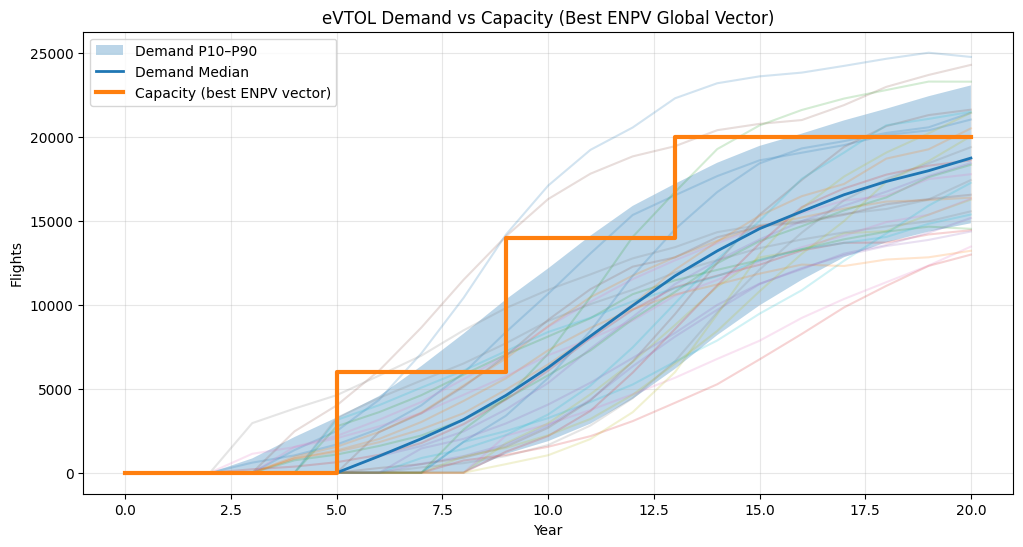

In [18]:
# ============================================================
# SETTINGS
# ============================================================

# Number of planning years
n_years = 20

# Discount rate used to discount future cash flows
discount_rate = 0.04

# Annual capacity provided by one stand
capacity_per_stand_per_year = 2000

# Set of feasible stand decisions in each year
stand_range = range(0, 41)

# Number of random demand paths shown in the overview plot
n_example_paths = 30

# Revenue parameters
fee_evtol = 250
charging_fee_evtol = 100

# OPEX parameters
# maintenance: fixed annual cost per installed stand
# usage_cost: variable cost per served flight
maintenance = 50000
usage_cost = 120

# CAPEX parameters
# alpha controls the non-linearity of expansion costs
# capex_cost is the base cost level for expansions
alpha = 0.4
capex_cost = 300000

# Seed for reproducible random plot sampling
plot_seed = 42


# ============================================================
# OPEX FUNCTION
# ============================================================

def OPEX_Costs(Demand, Capacity, Stands, maintenance=50000, usage_cost=120):
    """
    Compute annual operating costs.

    Parameters
    ----------
    Demand : array-like
        Demand in number of flights.
    Capacity : array-like or scalar
        Available capacity in number of flights.
    Stands : array-like or scalar
        Number of installed stands.
    maintenance : float
        Fixed annual maintenance cost per stand.
    usage_cost : float
        Variable operating cost per served flight.

    Returns
    -------
    array-like
        Total OPEX = fixed stand maintenance + variable usage cost.
    """
    used_flights = np.minimum(Demand, Capacity)
    return maintenance * Stands + usage_cost * used_flights


# ============================================================
# DEMAND SCENARIOS
# ============================================================

# Combine baseline aircraft movements with eVTOL adoption paths
# Resulting shape: (years, scenarios)
evtol_flight_scenarios = movement_scenarios * evtol_paths.T


# ============================================================
# DYNAMIC PROGRAMMING
# ONE GLOBAL CAPACITY VECTOR OVER ALL SCENARIOS
# ============================================================

def evaluate_global_capacity_vector_dp(scenarios):
    """
    Find one single non-decreasing stand vector that maximizes ENPV
    across all demand scenarios.

    Decision structure
    ------------------
    - In each year t, choose one stand level s_t
    - The same decision is applied to all scenarios
    - Capacity reductions are not allowed

    Returns
    -------
    enpv : float
        Expected NPV across all scenarios for the optimal global vector.
    npv : ndarray
        Scenario-wise NPV values under the optimal global vector.
    chosen_stands_history : ndarray
        Optimal global stand vector over time.
    """

    # Number of scenarios
    n_paths = scenarios.shape[1]

    # Discrete stand values that can be chosen
    stand_values = np.array(list(stand_range))
    n_stands = len(stand_values)

    # Value table:
    # V[t, i] = best discounted expected value from year t onward,
    # given that the current installed stand level before year t is stand_values[i]
    V = np.zeros((n_years + 2, n_stands))

    # Policy table:
    # policy[t, i] = optimal stand choice in year t,
    # given current stands = stand_values[i]
    policy = np.zeros((n_years + 1, n_stands), dtype=int)

    # --------------------------------------------------------
    # Backward recursion
    # --------------------------------------------------------
    # Solve the problem from the last year back to year 1
    for t in range(n_years, 0, -1):

        # Demand of all scenarios in year t
        demand_t = scenarios[t, :]

        # Loop over all possible current stand levels
        for i, current_stands in enumerate(stand_values):

            # Only non-decreasing stand levels are feasible
            feasible_stands = stand_values[stand_values >= current_stands]

            best_value = -np.inf
            best_next_stands = current_stands

            # Evaluate all feasible stand choices for year t
            for new_stands in feasible_stands:

                # Convert chosen stands into annual capacity
                capacity_t = new_stands * capacity_per_stand_per_year

                # Revenue for all scenarios in year t
                revenue_t = revenue(
                    landing_fee(demand_t, capacity_t, fee_evtol),
                    charging_fee(demand_t, capacity_t, charging_fee_evtol)
                )

                # OPEX for all scenarios in year t
                opex_t = OPEX_Costs(
                    demand_t,
                    capacity_t,
                    new_stands,
                    maintenance,
                    usage_cost
                )

                # CAPEX is deterministic because the same decision is used
                # for all scenarios
                if new_stands > current_stands:
                    capex_t = CAPEX(
                        np.array([current_stands]),
                        np.array([new_stands]),
                        alpha,
                        capex_cost
                    )[0]
                else:
                    capex_t = 0.0

                # Scenario-wise cash flow in year t
                cashflow_t = revenue_t - opex_t - capex_t

                # Expected discounted one-period contribution
                expected_value_t = np.mean(cashflow_t) / ((1 + discount_rate) ** t)

                # Add continuation value from next year onward
                j = np.where(stand_values == new_stands)[0][0]
                total_value = expected_value_t + V[t + 1, j]

                # Keep the best feasible decision
                if total_value > best_value:
                    best_value = total_value
                    best_next_stands = new_stands

            # Store optimal value and policy
            V[t, i] = best_value
            policy[t, i] = best_next_stands

    # --------------------------------------------------------
    # Forward pass: reconstruct optimal global stand vector
    # --------------------------------------------------------

    # Store optimal stand choice for each year
    chosen_stands_history = np.zeros(n_years + 1, dtype=int)

    # Assume zero initial stands in year 0
    current_stands = 0
    chosen_stands_history[0] = current_stands

    # Follow the stored policy from year 1 to year n_years
    for t in range(1, n_years + 1):
        i = np.where(stand_values == current_stands)[0][0]
        next_stands = policy[t, i]
        chosen_stands_history[t] = next_stands
        current_stands = next_stands

    # --------------------------------------------------------
    # Compute scenario-wise NPV under the optimal global vector
    # --------------------------------------------------------

    npv = np.zeros(n_paths)

    for t in range(1, n_years + 1):
        stands_t = chosen_stands_history[t]
        stands_prev = chosen_stands_history[t - 1]

        demand_t = scenarios[t, :]
        capacity_t = stands_t * capacity_per_stand_per_year

        # Revenue in year t
        revenue_t = revenue(
            landing_fee(demand_t, capacity_t, fee_evtol),
            charging_fee(demand_t, capacity_t, charging_fee_evtol)
        )

        # OPEX in year t
        opex_t = OPEX_Costs(
            demand_t,
            capacity_t,
            stands_t,
            maintenance,
            usage_cost
        )

        # CAPEX in year t if capacity is expanded
        if stands_t > stands_prev:
            capex_t = CAPEX(
                np.array([stands_prev]),
                np.array([stands_t]),
                alpha,
                capex_cost
            )[0]
        else:
            capex_t = 0.0

        # Discounted yearly contribution to scenario-wise NPV
        cashflow_t = revenue_t - opex_t - capex_t
        npv += cashflow_t / ((1 + discount_rate) ** t)

    # Expected NPV across all scenarios
    enpv = np.mean(npv)

    return enpv, npv, chosen_stands_history


# ============================================================
# RUN OPTIMIZATION
# ============================================================

# Solve for the optimal global stand vector
best_enpv, npv_dist, chosen_stands_history = evaluate_global_capacity_vector_dp(
    evtol_flight_scenarios
)

# Print summary results
print("--- eVTOL OPTIMUM (DYNAMIC PROGRAMMING, GLOBAL VECTOR) ---")
print(f"ENPV: {best_enpv:,.2f}")
print(f"Optimal stand vector: {chosen_stands_history}")


# ============================================================
# PREPARE DATA FOR PLOT
# ============================================================

# Time axis from year 0 to year n_years
years = np.arange(n_years + 1)

# Reformat demand scenarios for plotting
# Shape: (scenarios, time)
demand_paths = evtol_flight_scenarios.T

# Demand distribution over time
q10 = np.quantile(demand_paths, 0.10, axis=0)
q50 = np.quantile(demand_paths, 0.50, axis=0)
q90 = np.quantile(demand_paths, 0.90, axis=0)

# Randomly select example demand paths for visualization
rng = np.random.default_rng(plot_seed)
idx = rng.choice(
    demand_paths.shape[0],
    size=min(n_example_paths, demand_paths.shape[0]),
    replace=False
)

# Convert optimal stand vector into annual flight capacity
capacity_best = chosen_stands_history * capacity_per_stand_per_year


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(12, 6))

# Plot randomly selected demand scenarios
plt.plot(years, demand_paths[idx].T, alpha=0.2)

# Plot uncertainty band between 10th and 90th percentile
plt.fill_between(years, q10, q90, alpha=0.3, label="Demand P10–P90")

# Plot median demand path
plt.plot(years, q50, linewidth=2, label="Demand Median")

# Plot optimal global capacity vector
plt.step(
    years,
    capacity_best,
    where="post",
    linewidth=3,
    label="Capacity (best ENPV vector)"
)

plt.xlabel("Year")
plt.ylabel("Flights")
plt.title("eVTOL Demand vs Capacity (Best ENPV Global Vector)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# SAVE RESULTS UNDER UNIQUE NAMES
# ============================================================

# Store results under explicit names for later reuse
best_enpv_conv = best_enpv
npv_dist_conv = npv_dist
chosen_stands_history_conv = chosen_stands_history

#### Flexible

--- OPTIMAL FLEXIBLE eVTOL STRATEGY ---
Best ENPV: 17,260,917.72
Best threshold buffer: 0
Best stand addition: 3


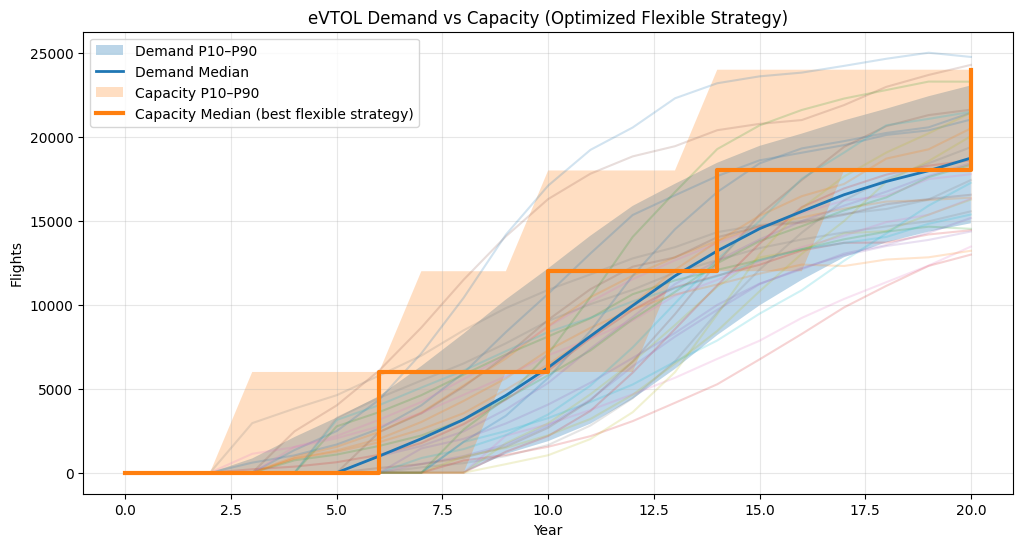

In [19]:
# ============================================================
# SETTINGS
# ============================================================

# Parameters to optimize
threshold_buffer_values = np.arange(0, capacity_per_stand_per_year + 1, 10)
stand_add_values = [0,3,4,5,6,7,8]
plot_seed = 42


# ============================================================
# OPEX FUNCTION
# ============================================================

def OPEX_Costs(Demand, Capacity, Stands, maintenance=50000, usage_cost=120):
    """
    Calculate annual operating expenditures.

    Parameters
    ----------
    Demand : array-like
        Demand in flights for the current year.
    Capacity : array-like or scalar
        Installed capacity in flights for the current year.
    Stands : array-like or scalar
        Number of installed stands in the current year.
    maintenance : float, optional
        Annual maintenance cost per stand.
    usage_cost : float, optional
        Variable operating cost per used flight.

    Returns
    -------
    array-like
        Total OPEX for the current year.
    """
    used_flights = np.minimum(Demand, Capacity)
    return maintenance * Stands + usage_cost * used_flights


# ============================================================
# DEMAND SCENARIOS
# ============================================================

# Combine total movement scenarios with eVTOL adoption paths
# Resulting shape: (years, scenarios)
evtol_flight_scenarios = movement_scenarios * evtol_paths.T


# ============================================================
# FLEXIBLE STRATEGY EVALUATION
# ============================================================

def evaluate_flexible_evtol(scenarios, threshold_buffer, stand_add):
    """
    Evaluate a flexible expansion policy across all demand scenarios.

    Policy logic:
    - Start with zero stands
    - In each year, compare demand with current capacity minus a buffer
    - If demand exceeds this threshold, add a fixed number of stands

    Parameters
    ----------
    scenarios : ndarray
        Demand scenarios with shape (years, scenarios).
    threshold_buffer : float or int
        Buffer below current capacity that triggers an expansion.
    stand_add : int
        Number of stands added whenever the expansion rule is triggered.

    Returns
    -------
    enpv : float
        Expected NPV across all scenarios.
    npv : ndarray
        Scenario-wise NPV values.
    chosen_stands_history : ndarray
        Stand history for all scenarios, shape (n_years + 1, n_paths).
    """
    n_paths = scenarios.shape[1]

    # Store NPV for each scenario
    npv = np.zeros(n_paths)

    # Current number of stands for each scenario
    current_stands = np.zeros(n_paths)

    # Store stand decisions over time for each scenario
    chosen_stands_history = np.zeros((n_years + 1, n_paths))

    # Initial state in year 0
    chosen_stands_history[0, :] = current_stands

    for t in range(1, n_years + 1):
        demand_t = scenarios[t, :]

        # Installed capacity before a possible expansion in year t
        current_capacity = current_stands * capacity_per_stand_per_year

        # Expansion rule:
        # expand if demand is above capacity minus the threshold buffer
        expand_mask = demand_t > (current_capacity - threshold_buffer)

        # Apply stand additions only to scenarios where the rule is triggered
        new_stands = current_stands.copy()
        new_stands[expand_mask] += stand_add

        # Capacity after the potential expansion
        new_capacity = new_stands * capacity_per_stand_per_year

        # Annual revenues
        revenue_t = revenue(
            landing_fee(demand_t, new_capacity, fee_evtol),
            charging_fee(demand_t, new_capacity, charging_fee_evtol)
        )

        # Annual operating costs
        opex_t = OPEX_Costs(
            demand_t,
            new_capacity,
            new_stands,
            maintenance,
            usage_cost
        )

        # Annual investment costs only where new stands were added
        capex_t = np.zeros(n_paths)
        expansion_mask = new_stands > current_stands

        if np.any(expansion_mask):
            capex_t[expansion_mask] = CAPEX(
                current_stands[expansion_mask],
                new_stands[expansion_mask],
                alpha,
                capex_cost
            )

        # Net cash flow in year t
        cashflow_t = revenue_t - opex_t - capex_t

        # Discounted cash flow contribution
        npv += cashflow_t / ((1 + discount_rate) ** t)

        # Update stand state for next year
        current_stands = new_stands
        chosen_stands_history[t, :] = current_stands

    return np.mean(npv), npv, chosen_stands_history


# ============================================================
# GRID SEARCH FOR BEST FLEXIBLE POLICY
# ============================================================

best_enpv = -np.inf
best_threshold_buffer = None
best_stand_add = None
best_npv_dist = None
best_chosen_stands_history = None

# Evaluate all combinations of threshold buffer and stand addition
for threshold_buffer in threshold_buffer_values:
    for stand_add in stand_add_values:
        enpv, npv_dist_candidate, chosen_stands_history_candidate = evaluate_flexible_evtol(
            evtol_flight_scenarios,
            threshold_buffer,
            stand_add
        )

        # Keep the policy with the highest expected NPV
        if enpv > best_enpv:
            best_enpv = enpv
            best_threshold_buffer = threshold_buffer
            best_stand_add = stand_add
            best_npv_dist = npv_dist_candidate.copy()
            best_chosen_stands_history = chosen_stands_history_candidate.copy()

print("--- OPTIMAL FLEXIBLE eVTOL STRATEGY ---")
print(f"Best ENPV: {best_enpv:,.2f}")
print(f"Best threshold buffer: {best_threshold_buffer}")
print(f"Best stand addition: {best_stand_add}")


# ============================================================
# PREPARE DATA FOR PLOT
# ============================================================

years = np.arange(n_years + 1)

# Transpose to shape: (scenarios, time)
demand_paths = evtol_flight_scenarios.T

# Demand percentiles across scenarios
demand_p10 = np.quantile(demand_paths, 0.10, axis=0)
demand_p50 = np.quantile(demand_paths, 0.50, axis=0)
demand_p90 = np.quantile(demand_paths, 0.90, axis=0)

# Randomly select example demand paths for visualization
rng = np.random.default_rng(plot_seed)
selected_path_indices = rng.choice(
    demand_paths.shape[0],
    size=min(n_example_paths, demand_paths.shape[0]),
    replace=False
)

# Flexible strategy generates scenario-specific capacity paths
capacity_paths = best_chosen_stands_history * capacity_per_stand_per_year

# Capacity percentiles across scenarios
capacity_p10 = np.quantile(capacity_paths, 0.10, axis=1)
capacity_p50 = np.quantile(capacity_paths, 0.50, axis=1)
capacity_p90 = np.quantile(capacity_paths, 0.90, axis=1)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(12, 6))

# Plot example demand paths
plt.plot(years, demand_paths[selected_path_indices].T, alpha=0.2)

# Plot demand uncertainty band
plt.fill_between(years, demand_p10, demand_p90, alpha=0.3, label="Demand P10–P90")

# Plot median demand
plt.plot(years, demand_p50, linewidth=2, label="Demand Median")

# Plot capacity uncertainty band of the optimal flexible strategy
plt.fill_between(
    years,
    capacity_p10,
    capacity_p90,
    alpha=0.25,
    label="Capacity P10–P90"
)

# Plot median capacity path
plt.step(
    years,
    capacity_p50,
    where="post",
    linewidth=3,
    label="Capacity Median (best flexible strategy)"
)

plt.xlabel("Year")
plt.ylabel("Flights")
plt.title("eVTOL Demand vs Capacity (Optimized Flexible Strategy)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# SAVE FLEXIBLE RESULTS UNDER UNIQUE NAMES
# ============================================================

best_enpv_flex = best_enpv
npv_dist_flex = best_npv_dist
chosen_stands_history_flex = best_chosen_stands_history
best_threshold_buffer_flex = best_threshold_buffer
best_stand_add_flex = best_stand_add

## 8. Compare the optimal ENPV values

Compare the **optimal ENPV values** obtained for the **conventional** and **flexible** planning approaches.

In addition, **plot the target curves** for both:

- the **conventionally planned system**
- the **flexibly planned system**

---

### Documentation

Discuss the results:

- Does the **comparison align with your expectations**?
- What **conclusions and insights** do you draw from comparing **conventional and flexible planning**?

---

#### Histogram NPV Distribution

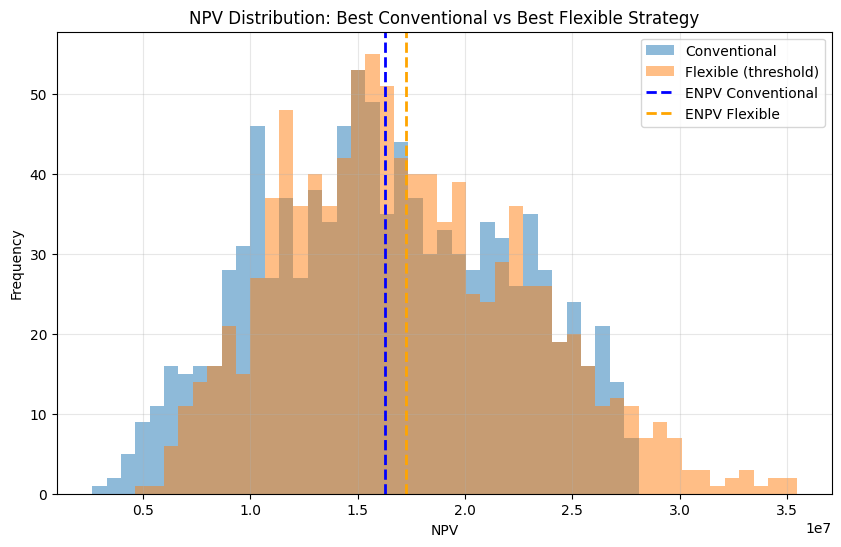

In [20]:
# ============================================================
# HISTOGRAM: BEST CONVENTIONAL VS BEST FLEXIBLE
# ============================================================

plt.figure(figsize=(10, 6))

# Combine both distributions to compute common bins
all_npv = np.concatenate([npv_dist_conv, npv_dist_flex])

bins = np.linspace(
    np.min(all_npv),
    np.max(all_npv),
    50
)

# Conventional (best global capacity vector)
plt.hist(
    npv_dist_conv,
    bins=bins,
    alpha=0.5,
    label="Conventional"
)

# Flexible (best global rule)
plt.hist(
    npv_dist_flex,
    bins=bins,
    alpha=0.5,
    label="Flexible (threshold)"
)

# ENPV lines
plt.axvline(
    best_enpv_conv,
    linestyle="--",
    linewidth=2,
    color="blue",
    label="ENPV Conventional"
)

plt.axvline(
    best_enpv_flex,
    linestyle="--",
    linewidth=2,
    color="orange",
    label="ENPV Flexible"
)

plt.xlabel("NPV")
plt.ylabel("Frequency")
plt.title("NPV Distribution: Best Conventional vs Best Flexible Strategy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#### CDF NPV Distribution

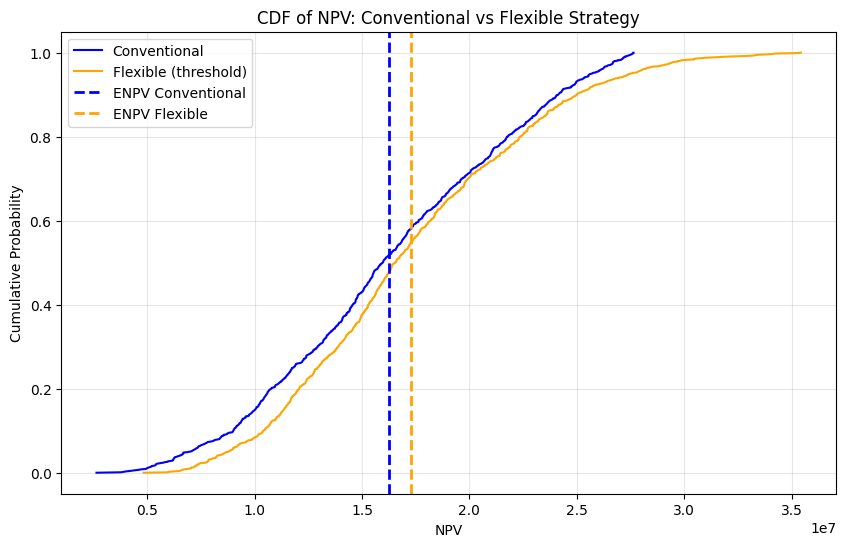

In [21]:
plt.figure(figsize=(10, 6))

# Sort NPV values
x_conv = np.sort(npv_dist)
x_flex = np.sort(npv_dist_flex)

# Empirical CDF
y_conv = np.arange(1, len(x_conv) + 1) / len(x_conv)
y_flex = np.arange(1, len(x_flex) + 1) / len(x_flex)

# Plot CDFs
plt.plot(x_conv, y_conv, label="Conventional", color="blue")
plt.plot(x_flex, y_flex, label="Flexible (threshold)", color="orange")

# ENPV lines
plt.axvline(
    np.mean(npv_dist),
    linestyle="--",
    linewidth=2,
    color="blue",
    label="ENPV Conventional"
)

plt.axvline(
    np.mean(npv_dist_flex),
    linestyle="--",
    linewidth=2,
    color="orange",
    label="ENPV Flexible"
)

plt.xlabel("NPV")
plt.ylabel("Cumulative Probability")
plt.title("CDF of NPV: Conventional vs Flexible Strategy")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

#### There is an obvious shift in the distribution between the conventional and the flexible approach. In addition, the flexible strategy exhibits a much larger tail, indicating that flexible planning is better suited for long-term planning under uncertainty.

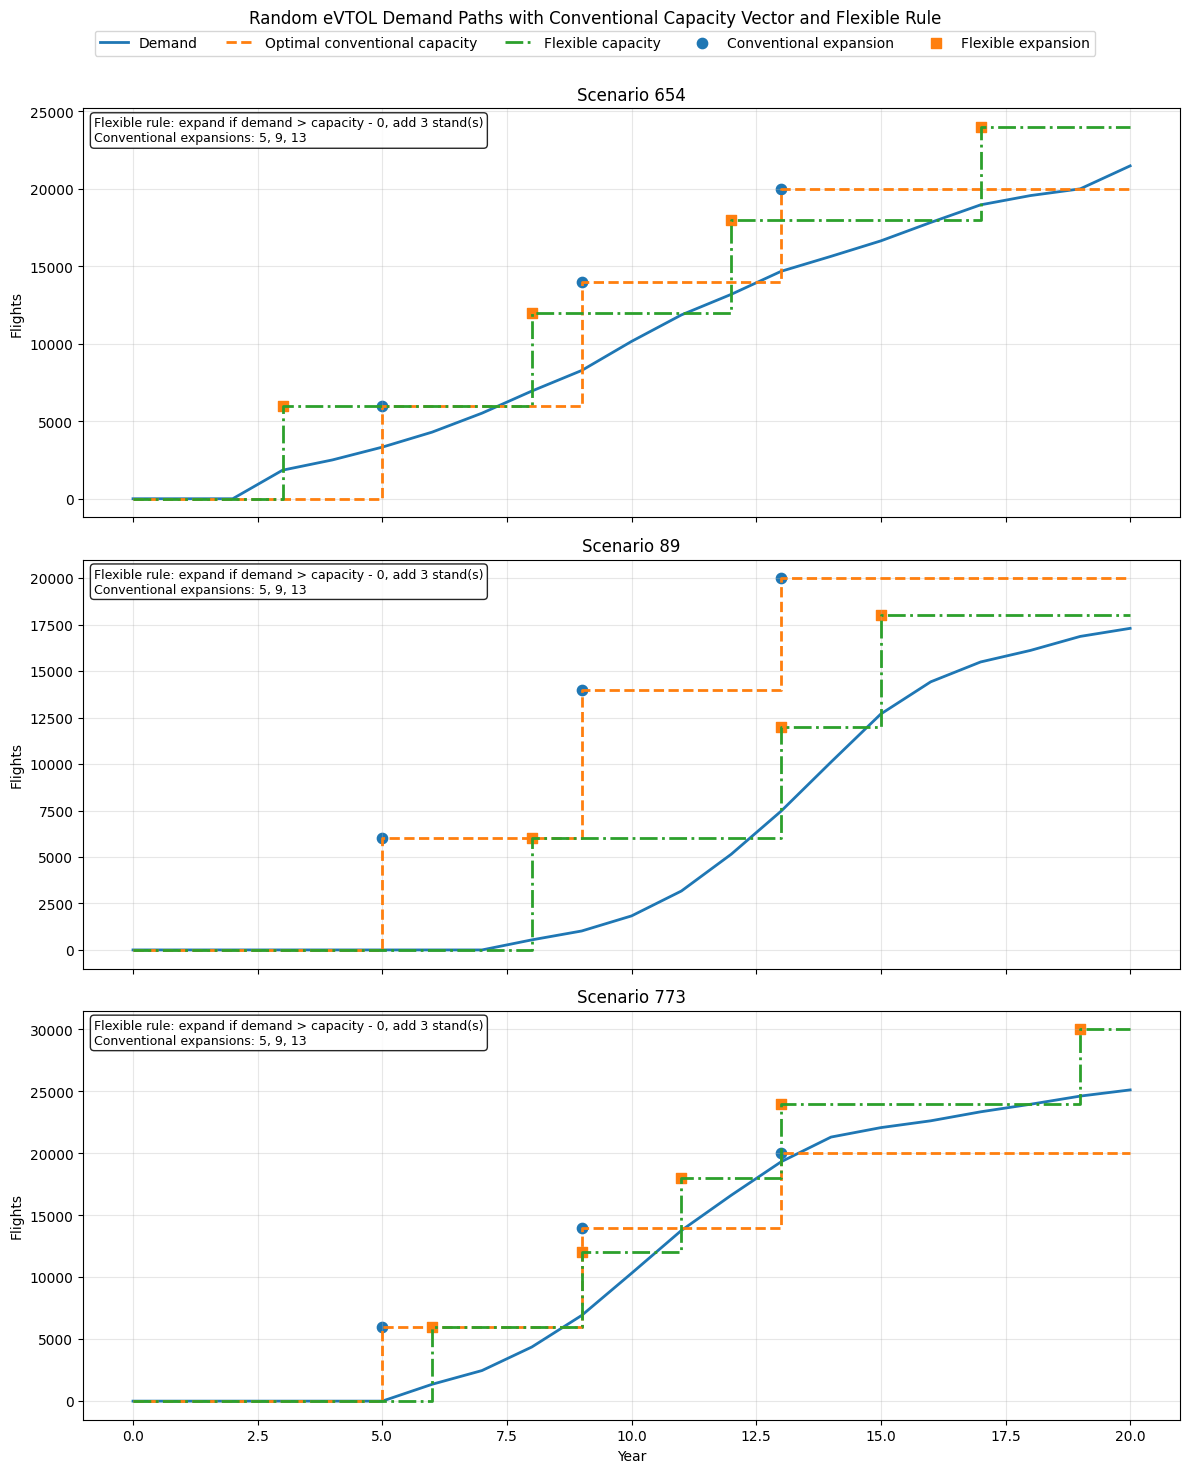

In [22]:
# ============================================================
# SETTINGS
# ============================================================

n_plot_paths = 3


# ============================================================
# PREPARE DATA
# ============================================================

years = np.arange(n_years + 1)
demand_paths = evtol_flight_scenarios.T

# Randomly select demand scenarios to display
rng = np.random.default_rng(plot_seed)
selected_idx = rng.choice(
    demand_paths.shape[0],
    size=min(n_plot_paths, demand_paths.shape[0]),
    replace=False
)

# ------------------------------------------------------------
# Conventional: one single optimal capacity vector
# ------------------------------------------------------------
best_conv_idx = np.argmax(npv_dist)
capacity_conv_opt = chosen_stands_history * capacity_per_stand_per_year

conv_expand_mask = np.diff(capacity_conv_opt) > 0
conv_expand_years = years[1:][conv_expand_mask]
conv_expand_values = capacity_conv_opt[1:][conv_expand_mask]

if len(conv_expand_years) > 0:
    conv_expansion_text = "Conventional expansions: " + ", ".join(map(str, conv_expand_years))
else:
    conv_expansion_text = "Conventional expansions: none"

# ------------------------------------------------------------
# Flexible: optimal rule
# ------------------------------------------------------------
flex_rule_text = (
    f"Flexible rule: expand if demand > capacity - {best_threshold_buffer}, "
    f"add {best_stand_add} stand(s)"
)


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    len(selected_idx), 1,
    figsize=(12, 4.8 * len(selected_idx)),
    sharex=True
)

axes = np.atleast_1d(axes)

for ax, scenario_idx in zip(axes, selected_idx):
    demand = demand_paths[scenario_idx]

    # Flexible capacity path depends on the specific demand scenario
    cap_flex = best_chosen_stands_history[:, scenario_idx] * capacity_per_stand_per_year

    flex_expand_mask = np.diff(cap_flex) > 0
    flex_expand_years = years[1:][flex_expand_mask]
    flex_expand_values = cap_flex[1:][flex_expand_mask]

    # Demand path
    ax.plot(
        years,
        demand,
        linewidth=2,
        label="Demand"
    )

    # Same optimal conventional capacity vector in every subplot
    ax.step(
        years,
        capacity_conv_opt,
        where="post",
        linewidth=2,
        linestyle="--",
        label="Optimal conventional capacity"
    )

    # Scenario-specific flexible capacity path
    ax.step(
        years,
        cap_flex,
        where="post",
        linewidth=2,
        linestyle="-.",
        label="Flexible capacity"
    )

    # Mark conventional expansions
    ax.scatter(
        conv_expand_years,
        conv_expand_values,
        s=55,
        marker="o",
        label="Conventional expansion"
    )

    # Mark flexible expansions
    ax.scatter(
        flex_expand_years,
        flex_expand_values,
        s=55,
        marker="s",
        label="Flexible expansion"
    )

    # Information box
    info_text = f"{flex_rule_text}\n{conv_expansion_text}"

    ax.text(
        0.01, 0.98,
        info_text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
    )

    ax.set_title(f"Scenario {scenario_idx}")
    ax.set_ylabel("Flights")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Year")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.01))

fig.suptitle(
    "Random eVTOL Demand Paths with Conventional Capacity Vector and Flexible Rule",
    y=1.02
)

fig.tight_layout()
plt.show()